# Dependensies and library

In [ ]:
# !pip install pyarrow fastparquet
# !pip install scikit-learn
# !pip install transformers datasets scikit-learn evaluate --quiet
!pip install nltk pymorphy2 stopwords-iso
!pip install scikit-multilearn
!pip install langdetect

ERROR: Could not find a version that satisfies the requirement stopwords-iso (from versions: none)
ERROR: No matching distribution found for stopwords-iso
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=872bcbcb90b38498057ad436f5fef778abacd6408443b561470940f0833e5950
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score
from sklearn.metrics import hamming_loss
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.naive_bayes import MultinomialNB
from skmultilearn.problem_transform import ClassifierChain
from skmultilearn.problem_transform import LabelPowerset



# Download data

 ## Download train dataset

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/Roberta_for_unlp/train (4).parquet')
print(df.shape)
df.head()

(3822, 6)


,id,content,lang,manipulative,techniques,trigger_words
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,Новий огляд мапи DeepState від російського вій...,uk,True,"[euphoria, loaded_language]","[[27, 63], [65, 88], [90, 183], [186, 308]]"
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,Недавно 95 квартал жёстко поглумился над русск...,ru,True,"[loaded_language, cherry_picking]","[[0, 40], [123, 137], [180, 251], [253, 274]]"
2,e6a427f1-211f-405f-bd8b-70798458d656,🤩\nТим часом йде евакуація Бєлгородського авто...,uk,True,"[loaded_language, euphoria]","[[55, 100]]"
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,В Україні найближчим часом мають намір посилит...,uk,False,None,None
4,9c01de00-841f-4b50-9407-104e9ffb03bf,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",ru,True,[loaded_language],"[[114, 144]]"


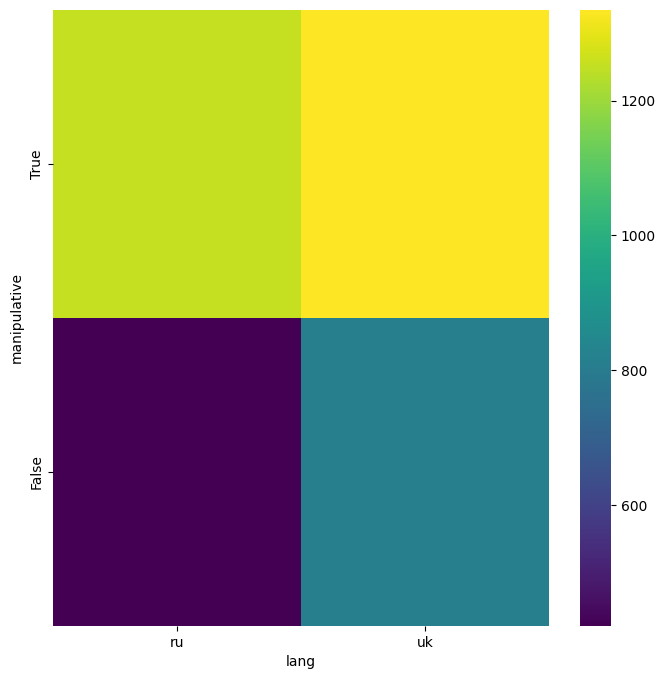

In [ ]:
# @title lang vs manipulative

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['manipulative'].value_counts()
    for x_label, grp in df.groupby('lang')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('lang')
_ = plt.ylabel('manipulative')

..

In [ ]:
# Fill NaN with empty list
df['techniques'] = df['techniques'].apply(lambda x: x if isinstance(x, np.ndarray) else [])

In [ ]:
mlb = MultiLabelBinarizer()
tech_matrix = mlb.fit_transform(df['techniques'])

# Add binary columns to the original dataframe
tech_df = pd.DataFrame(tech_matrix, columns=mlb.classes_)
df = pd.concat([df, tech_df], axis=1)

In [ ]:
train_data = df[['id', 'content', 'manipulative', 'lang'] + list(mlb.classes_)]
train_data.head()

,id,content,manipulative,lang,appeal_to_fear,bandwagon,cherry_picking,cliche,euphoria,fud,glittering_generalities,loaded_language,straw_man,whataboutism
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,Новий огляд мапи DeepState від російського вій...,True,uk,0,0,0,0,1,0,0,1,0,0
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,Недавно 95 квартал жёстко поглумился над русск...,True,ru,0,0,1,0,0,0,0,1,0,0
2,e6a427f1-211f-405f-bd8b-70798458d656,🤩\nТим часом йде евакуація Бєлгородського авто...,True,uk,0,0,0,0,1,0,0,1,0,0
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,В Україні найближчим часом мають намір посилит...,False,uk,0,0,0,0,0,0,0,0,0,0
4,9c01de00-841f-4b50-9407-104e9ffb03bf,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",True,ru,0,0,0,0,0,0,0,1,0,0


## Download test dataset

In [ ]:
# Load files
df_test = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/test.csv")
df_solution = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/solution.csv")

# Merge test and labels by 'id'
test_data = df_test.merge(df_solution, on='id')
test_data = test_data.drop(columns = 'Usage')

In [ ]:
test_data.head()

,id,content,straw_man,appeal_to_fear,fud,bandwagon,whataboutism,loaded_language,glittering_generalities,euphoria,cherry_picking,cliche
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...",0,0,1,0,0,1,0,0,0,0
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,0,0,0,0,0,1,0,0,0,0
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,0,0,0,0,0,1,0,0,0,0
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,0,0,0,0,0,0,0,0,0,0
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,0,0,0,0,0,1,0,0,0,0


Reordering test dataset columns

In [ ]:
test_data =test_data[['id', 'content'] + list(mlb.classes_)]
test_data.head()

,id,content,appeal_to_fear,bandwagon,cherry_picking,cliche,euphoria,fud,glittering_generalities,loaded_language,straw_man,whataboutism
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...",0,0,0,0,0,1,0,1,0,0
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,0,0,0,0,0,0,0,1,0,0
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,0,0,0,0,0,0,0,1,0,0
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,0,0,0,0,0,0,0,0,0,0
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,0,0,0,0,0,0,0,1,0,0


# EDA(with train dataset in future also feature creation)

## Insigths about data

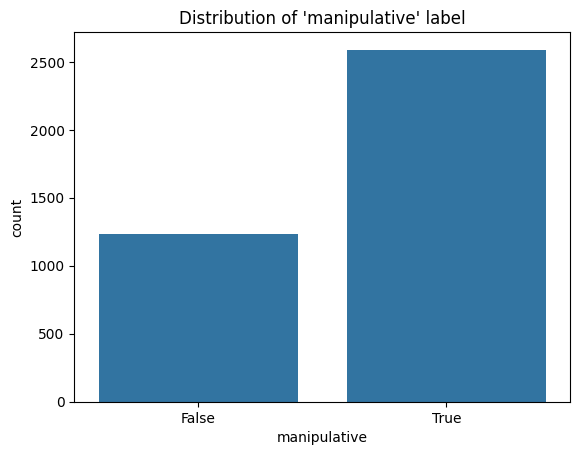

In [ ]:
sns.countplot(data=train_data, x='manipulative')
plt.title("Distribution of 'manipulative' label")
plt.show()

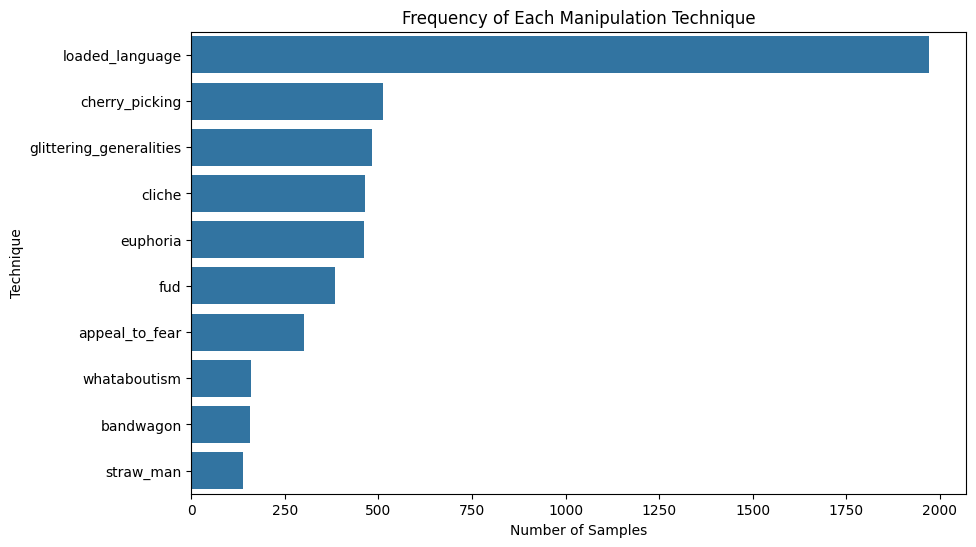

In [ ]:
technique_counts = train_data[mlb.classes_].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=technique_counts.values, y=technique_counts.index)
plt.title("Frequency of Each Manipulation Technique")
plt.xlabel("Number of Samples")
plt.ylabel("Technique")
plt.show()

<ipython-input-14-73e1eb9bb285>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['n_techniques'] = train_data[mlb.classes_].sum(axis=1)


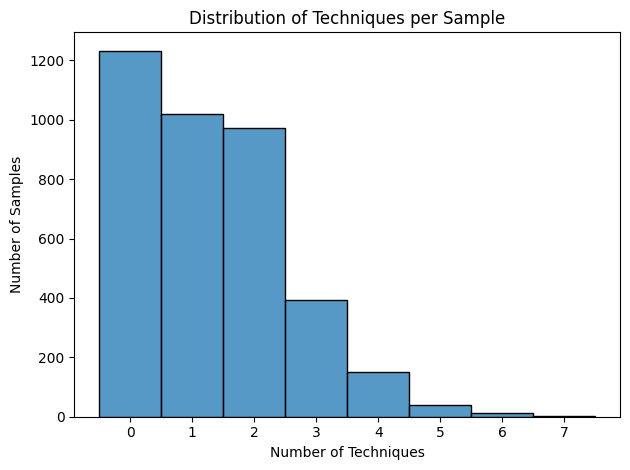

In [ ]:
train_data['n_techniques'] = train_data[mlb.classes_].sum(axis=1)

# sns.histplot(train_data['n_techniques'], bins=10)
# plt.title("Distribution of Techniques per Sample")
# plt.xlabel("Number of Techniques")
# plt.ylabel("Number of Samples")
# plt.show()

# Plot histogram with better formatting
sns.histplot(train_data['n_techniques'], bins=range(0, train_data['n_techniques'].max() + 2), discrete=True)

plt.title("Distribution of Techniques per Sample")
plt.xlabel("Number of Techniques")
plt.ylabel("Number of Samples")

# Show integer ticks only
plt.xticks(np.arange(0, train_data['n_techniques'].max() + 1))

plt.tight_layout()
plt.show()

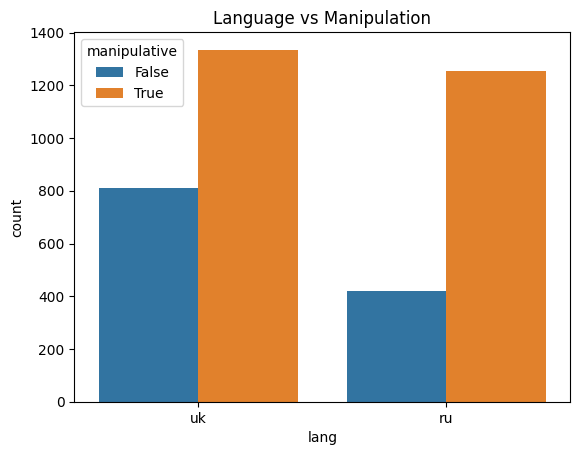

In [ ]:
sns.countplot(data=train_data, x='lang', hue='manipulative')
plt.title("Language vs Manipulation")
plt.show()

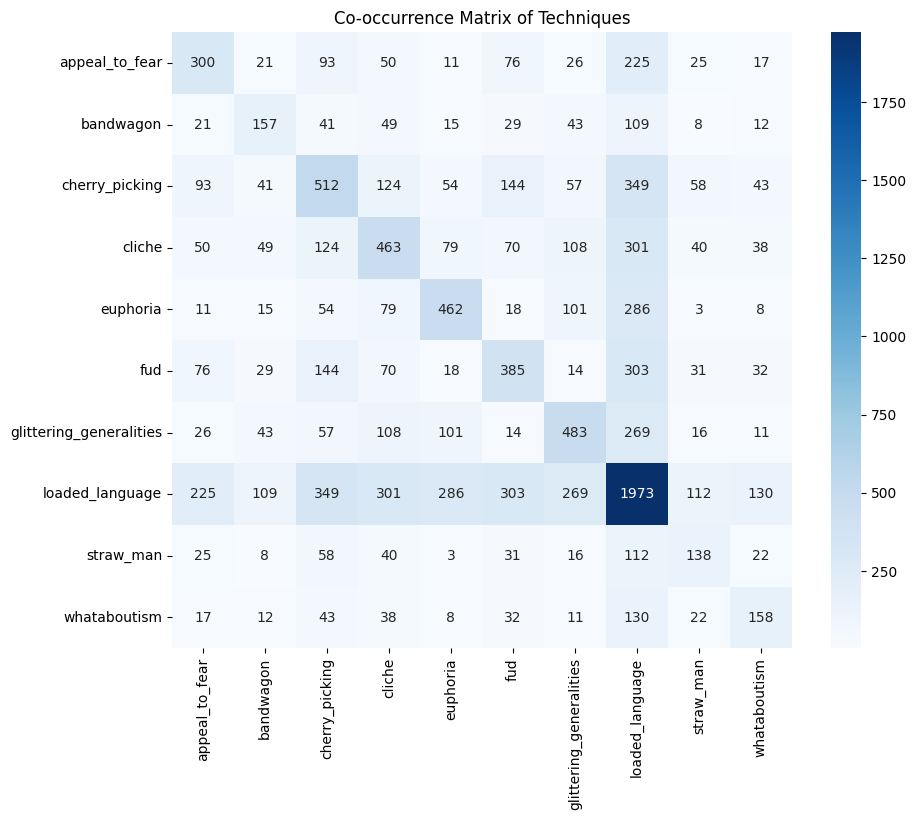

In [ ]:
co_occurrence = train_data[mlb.classes_].T.dot(train_data[mlb.classes_])
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Blues')
plt.title("Co-occurrence Matrix of Techniques")
plt.show()

## Features for future work with it for my models

In [ ]:
!pip install stopwordsiso

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.2 MB/s eta 0:00:00


In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from stopwordsiso import stopwords as stopwords_iso

# Download NLTK stopwords
nltk.download('stopwords')

# Combine stopwords from nltk and stopwords-iso
stopwords_ru = set(stopwords.words('russian')) | stopwords_iso('ru')
stopwords_uk = stopwords_iso('uk')




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
train_data['content']

,content
0,Новий огляд мапи DeepState від російського вій...
1,Недавно 95 квартал жёстко поглумился над русск...
2,🤩\nТим часом йде евакуація Бєлгородського авто...
3,В Україні найближчим часом мають намір посилит...
4,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад..."
...,...
3817,🤭\nросія ставить ППО на дахах адмінбудівель\nр...
3818,"К слову, Бабий не просто «ларечник», а и челов..."
3819,"Глава ФСБ Бортников ответил журналистам, почем..."
3820,В ДНР завозили наркотики в бытовой технике\nОб...


In [ ]:
# Function to preprocess a single text
def preprocess_text(text, lang):
    # # Lowercase
    # text = text.lower()

    # Remove punctuation and digits, URL, whitespaces
    # text = re.sub(r'[^а-яА-ЯёЁіїєґІЇЄҐa-zA-Z\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # # Remove stopwords based on language
    # if lang == 'ru':
    #     words = [w for w in words if w not in stopwords_ru]
    # elif lang == 'uk':
    #     words = [w for w in words if w not in stopwords_uk]

    return " ".join(words)

In [ ]:
from langdetect import detect
# def define_language(text):
#    detect(x) if isinstance(x, str) else 'unknown'


test_data['lang'] = test_data['content'].apply(lambda x: detect(x) if isinstance(x, str) else 'unknown')


In [ ]:
test_data = test_data[(test_data['lang'] == 'ru') | (test_data['lang'] == 'uk')]
test_data = test_data.reset_index(drop=True)

In [ ]:
train_data['clean_text'] = train_data.apply(
    lambda row: preprocess_text(row['content'], row['lang']), axis=1
)

In [ ]:
test_data['clean_text'] = test_data.apply(
    lambda row: preprocess_text(row['content'], row['lang']), axis=1
)

In [ ]:
def extract_custom_features(df):
    return pd.DataFrame({
        "text_len": df['content'].apply(len),
        "word_count": df['content'].apply(lambda x: len(x.split())),
        "avg_word_len": df['content'].apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0),
        "num_exclam": df['content'].str.count('!'),
        "num_question": df['content'].str.count('\?'),
        "num_uppercase_words": df['content'].apply(lambda x: sum(1 for w in x.split() if w.isupper())),
        "num_emojis": df['content'].str.count(r'[\U0001F600-\U0001F64F]'),  # Emoji range
    })


# Classic models without features

## Final test set

In [ ]:
X_final_test = test_data['clean_text']
y_final_test = test_data[mlb.classes_]

## Split train dataset

In [ ]:
# X = train_data['clean_text']
# y = train_data[mlb.classes_]
# #random_state sets a seed, the train-test splits are always deterministic. If the seed is not set, train-test splits are different each time
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

## Generate features

In [ ]:
import string
from textblob import TextBlob
import re
import pandas as pd
from typing import Dict
import spacy

Pronouns count + punctiation


In [ ]:
# Custom pronouns list (UA + RU)
COMMON_PRONOUNS = set([
    "я", "ти", "він", "вона", "воно", "ми", "ви", "вони",
    "мене", "тебе", "його", "її", "нас", "вас", "їх",
    "мені", "тобі", "йому", "їй", "нам", "вам", "їм",
    "мій", "твій", "його", "її", "наш", "ваш", "їхній",
    "себе", "собі", "себе", "собою",
    "я", "ты", "он", "она", "оно", "мы", "вы", "они",
    "меня", "тебя", "его", "её", "нас", "вас", "их",
    "мне", "тебе", "ему", "ей", "нам", "вам", "им",
    "мой", "твой", "его", "её", "наш", "ваш", "их",
    "себя", "себе", "собой"
])


In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm import tqdm

# --- 1. Basic Feature Extractor ---
def extract_basic_features(texts):
    features = []
    for text in texts:
          words = re.findall(r'\b\w+\b', text)
          tokens = words

          # Text complexity
          total_chars = len(text)
          total_words = len(tokens)
          avg_word_len = total_chars / total_words if total_words > 0 else 0
          num_uppercase = sum(1 for c in text if c.isupper())
          num_punct = sum(1 for c in text if c in ".,!?;:")
          punct_ratio = num_punct / total_chars if total_chars > 0 else 0

          # Persuasion: Pronoun usage
          pronouns_used = sum(1 for t in tokens if t.lower() in COMMON_PRONOUNS)
          pronoun_ratio = pronouns_used / total_words if total_words > 0 else 0


          features.append({
              # Text complexity
              "num_words": total_words,
              "num_chars": total_chars,
              "avg_word_len": avg_word_len,
              "num_uppercase": num_uppercase,
              "num_punct": num_punct,
              "punct_ratio": punct_ratio,
              'num_exclamations': text.count('!'),
              'num_questions': text.count('\?'),

              # Persuasion
              "num_pronouns": pronouns_used,
              "pronoun_ratio": pronoun_ratio

          })

    return pd.DataFrame(features)

# --- 2. TF-IDF Features ---
def extract_tfidf_features(texts, test, max_features=10000):
    tfidf = TfidfVectorizer(ngram_range=(1, 1), max_features=max_features, min_df = 5, max_df=0.8)
    tfidf_matrix = tfidf.fit_transform(texts)
    test_m = tfidf.transform(test)
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"tfidf_{f}" for f in tfidf.get_feature_names_out()])
    test_df = pd.DataFrame(test_m.toarray(), columns=[f"tfidf_{f}" for f in tfidf.get_feature_names_out()])
    return tfidf_df, test_df

# --- 3. N-gram (CountVectorizer) Features ---
def extract_ngram_features(texts, test, max_features=200):
    ngram_vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=max_features)
    ngram_matrix = ngram_vectorizer.fit_transform(texts)
    test_m = ngram_vectorizer.transform(test)
    ngram_df = pd.DataFrame(ngram_matrix.toarray(), columns=[f"ngram_{f}" for f in ngram_vectorizer.get_feature_names_out()])
    test_df = pd.DataFrame(test_m.toarray(), columns=[f"ngram_{f}" for f in ngram_vectorizer.get_feature_names_out()])
    return ngram_df, test_df

def extract_language_feature(train, test):
  # Encode lang as binary features
  train_lang_features = pd.get_dummies(train.loc[train.index, 'lang'])
  final_test_lang_features = pd.get_dummies(test.loc[test.index, 'lang'])

  # train_lang_features = train_lang_features.reindex(columns=train_lang_features.columns, fill_value=0)
  # final_test_lang_features = final_test_lang_features.reindex(columns=train_lang_features.columns, fill_value=0)

  return train_lang_features, final_test_lang_features


def extract_sentiment_features(df, text_col, sentiment_model):
    """
    Applies a sentiment model to each row in the DataFrame and returns a new DataFrame with:
    - One-hot encoded sentiment label
    - Sentiment confidence score

    Parameters:
        df: pandas DataFrame
        text_col: name of column containing text
        sentiment_model: a function that accepts text and returns a list of dicts [{'label': 'Negative', 'score': 0.234}]

    Returns:
        DataFrame with new features
    """

    sentiment_map = {
    0: "Very Negative",
    1: "Negative",
    2: "Neutral",
    3: "Positive",
    4: "Very Positive"
    }
    sentiment_labels = list(sentiment_map.values())


    labels = []
    scores = []

    for text in tqdm(df[text_col]):
        result = sentiment_model(text)
        label = result[0]['label']
        score = result[0]['score']
        labels.append(label)
        scores.append(score)

    df_feat = pd.DataFrame()
    df_feat['sentiment_label'] = labels
    df_feat['sentiment_score'] = scores


    # One-hot encoding with predefined labels
    df_encoded = pd.get_dummies(df_feat['sentiment_label'], prefix='sentiment')
    for lbl in sentiment_labels:
        col_name = f'sentiment_{lbl}'
        if col_name not in df_encoded.columns:
            df_encoded[col_name] = 0

    # Reorder columns to keep consistency
    df_encoded = df_encoded[[f'sentiment_{lbl}' for lbl in sentiment_labels]]

    # Combine with score
    df_feat_final = pd.concat([df_encoded, df_feat[['sentiment_score']]], axis=1)

    return df_feat_final



TF-IDF

In [ ]:
tfidf_df, test_tfidf = extract_tfidf_features(train_data['clean_text'], X_final_test)

Ngram

In [ ]:
ngram_df, test_ngram = extract_ngram_features(train_data['clean_text'], X_final_test)

Basic features

In [ ]:
# Basic feature
basic_df = extract_basic_features(train_data['clean_text'])
basic_test = extract_basic_features(X_final_test)

Language feature

In [ ]:
train_lang, test_lang = extract_language_feature(train_data, test_data)

Sentiment analysis

In [ ]:
# from transformers import pipeline

# # Load the classification pipeline with the specified model
# pipe = pipeline("text-classification", model="tabularisai/multilingual-sentiment-analysis", truncation = True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/902 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# train_sentiment = extract_sentiment_features(train_data, 'clean_text', pipe)
# train_sentiment.to_csv('/content/drive/MyDrive/Roberta_for_unlp/sentiment_train.csv')
train_sentiment = pd.read_csv('/content/drive/MyDrive/Roberta_for_unlp/sentiment_train.csv')
train_sentiment = train_sentiment.drop(columns = 'Unnamed: 0')

In [ ]:
# test_sentiment = extract_sentiment_features(test_data,'clean_text', pipe)
# test_sentiment.to_csv('/content/drive/MyDrive/Roberta_for_unlp/sentiment_test.csv')
test_sentiment = pd.read_csv('/content/drive/MyDrive/Roberta_for_unlp/sentiment_test.csv')
test_sentiment = test_sentiment.drop(columns = 'Unnamed: 0')

In [ ]:
X = pd.concat([basic_df, tfidf_df, train_lang,train_sentiment, ngram_df], axis=1)
X_feat = pd.concat([basic_test, test_tfidf, test_lang, test_sentiment, test_ngram], axis=1)
X_feat = X_feat.dropna()

In [ ]:
y = train_data[mlb.classes_]
#random_state sets a seed, the train-test splits are always deterministic. If the seed is not set, train-test splits are different each time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced',solver='liblinear', C=10))
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.25      0.21      0.23        58
              bandwagon       0.12      0.11      0.12        35
         cherry_picking       0.38      0.40      0.39        97
                 cliche       0.17      0.17      0.17        93
               euphoria       0.35      0.42      0.38        77
                    fud       0.34      0.36      0.35        75
glittering_generalities       0.52      0.54      0.53        97
        loaded_language       0.69      0.68      0.68       392
              straw_man       0.11      0.12      0.12        25
           whataboutism       0.16      0.15      0.15        34

              micro avg       0.46      0.46      0.46       983
              macro avg       0.31      0.32      0.31       983
           weighted avg       0.46      0.46      0.46       983
            samples avg       0.34      0.33      0.31       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_final_test_pred = clf.predict(X_feat)

In [ ]:
print(classification_report(y_final_test[:-1], y_final_test_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.27      0.24      0.25       449
              bandwagon       0.15      0.11      0.12       236
         cherry_picking       0.36      0.39      0.38       768
                 cliche       0.23      0.21      0.22       694
               euphoria       0.38      0.39      0.38       694
                    fud       0.39      0.39      0.39       576
glittering_generalities       0.51      0.52      0.51       722
        loaded_language       0.68      0.67      0.67      2954
              straw_man       0.11      0.09      0.10       207
           whataboutism       0.15      0.13      0.14       235

              micro avg       0.47      0.46      0.47      7535
              macro avg       0.32      0.31      0.32      7535
           weighted avg       0.47      0.46      0.46      7535
            samples avg       0.33      0.32      0.30      7535



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# 1. Train OneVsRest Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# model = OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=1000))
# model.fit(X_train, y_train)

# 2. Predict probabilities
y_probs = clf.predict_proba(X_test)  # shape: [n_samples, n_classes]

# 3. Find best threshold per class using F1 score
def find_best_thresholds(y_true, y_probs, metric=f1_score):
    thresholds = []
    for i in range(y_true.shape[1]):
        best_thresh = 0.5
        best_score = 0
        for t in np.linspace(0.1, 0.9, 50):
            preds = (y_probs[:, i] >= t).astype(int)
            score = f1_score(y_true.iloc[:, i], preds, zero_division=0)
            if score > best_score:
                best_score = score
                best_thresh = t
        thresholds.append(best_thresh)
    return np.array(thresholds)

best_thresholds = find_best_thresholds(y_test, y_probs)
print("📌 Best thresholds per class:\n", best_thresholds)


📌 Best thresholds per class:
 [0.34489796 0.11632653 0.21428571 0.18163265 0.42653061 0.39387755
 0.65510204 0.29591837 0.11632653 0.5244898 ]


In [ ]:
y_final_prob = clf.predict_proba(X_feat)

In [ ]:
y_pred_custom = (y_final_prob >= best_thresholds).astype(int)

In [ ]:
print(classification_report(y_final_test[:-1], y_final_test_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.27      0.24      0.25       449
              bandwagon       0.15      0.11      0.12       236
         cherry_picking       0.36      0.39      0.38       768
                 cliche       0.23      0.21      0.22       694
               euphoria       0.38      0.39      0.38       694
                    fud       0.39      0.39      0.39       576
glittering_generalities       0.51      0.52      0.51       722
        loaded_language       0.68      0.67      0.67      2954
              straw_man       0.11      0.09      0.10       207
           whataboutism       0.15      0.13      0.14       235

              micro avg       0.47      0.46      0.47      7535
              macro avg       0.32      0.31      0.32      7535
           weighted avg       0.47      0.46      0.46      7535
            samples avg       0.33      0.32      0.30      7535



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from itertools import combinations
import pandas as pd
import numpy as np

# Feature parts
feature_parts_train = {
    "basic": basic_df,
    "tfidf": tfidf_df,
    "lang": train_lang,
    "sentiment": train_sentiment,
    "ngram": ngram_df
}

feature_parts_test = {
    "basic": basic_test,
    "tfidf": test_tfidf,
    "lang": test_lang,
    "sentiment": test_sentiment,
    "ngram": test_ngram
}

# Ground truths
y_true = y_final_test[:-1]  # assuming y_val is a DataFrame or array

# Store results
results = []

# Try all non-empty combinations of features
for r in range(1, len(feature_parts_train) + 1):
    for subset in combinations(feature_parts_train.keys(), r):
        name = "+".join(subset)

        # Merge selected features
        X_train_sub = pd.concat([feature_parts_train[f] for f in subset], axis=1)
        X_val_sub = pd.concat([feature_parts_test[f] for f in subset], axis=1)

        # print(X_train_sub.shape)
        # print(y_train.shape)
        # Train model
        clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced',solver='liblinear', C=10))
        clf.fit(X_train_sub, y)

        # Predict
        y_pred = clf.predict(X_val_sub[:5724])

        # Score
        f1 = f1_score(y_true, y_pred, average='macro')
        results.append((name, f1))
        print(f"✅ Tried: {name} | F1 (macro): {f1:.4f}")

# Sort and show best
results.sort(key=lambda x: x[1], reverse=True)
print("\n🏆 Top Feature Combinations:")
for name, score in results[:5]:
    print(f"{name}: {score:.4f}")


✅ Tried: basic | F1 (macro): 0.2730
✅ Tried: tfidf | F1 (macro): 0.3353
✅ Tried: lang | F1 (macro): 0.2400
✅ Tried: sentiment | F1 (macro): 0.2283
✅ Tried: ngram | F1 (macro): 0.2403
✅ Tried: basic+tfidf | F1 (macro): 0.3410
✅ Tried: basic+lang | F1 (macro): 0.2921
✅ Tried: basic+sentiment | F1 (macro): 0.2753
✅ Tried: basic+ngram | F1 (macro): 0.2778
✅ Tried: tfidf+lang | F1 (macro): 0.3362
✅ Tried: tfidf+sentiment | F1 (macro): 0.3349
✅ Tried: tfidf+ngram | F1 (macro): 0.3154
✅ Tried: lang+sentiment | F1 (macro): 0.2583
✅ Tried: lang+ngram | F1 (macro): 0.2576
✅ Tried: sentiment+ngram | F1 (macro): 0.2621
✅ Tried: basic+tfidf+lang | F1 (macro): 0.3399
✅ Tried: basic+tfidf+sentiment | F1 (macro): 0.3401
✅ Tried: basic+tfidf+ngram | F1 (macro): 0.3203
✅ Tried: basic+lang+sentiment | F1 (macro): 0.2980
✅ Tried: basic+lang+ngram | F1 (macro): 0.2870
✅ Tried: basic+sentiment+ngram | F1 (macro): 0.2817
✅ Tried: tfidf+lang+sentiment | F1 (macro): 0.3331
✅ Tried: tfidf+lang+ngram | F1 (macro

 ## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

clf = OneVsRestClassifier(MultinomialNB(alpha = 0.5))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       1.00      0.02      0.03        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.56      0.05      0.09        97
                 cliche       0.00      0.00      0.00        93
               euphoria       0.11      0.01      0.02        77
                    fud       0.00      0.00      0.00        75
glittering_generalities       0.77      0.21      0.33        97
        loaded_language       0.68      0.64      0.66       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.67      0.28      0.40       983
              macro avg       0.31      0.09      0.11       983
           weighted avg       0.47      0.28      0.31       983
            samples avg       0.34      0.21      0.24       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
y_final_test_pred = clf.predict(X_feat)

In [ ]:
print(classification_report(y_final_test, y_final_test_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00       449
              bandwagon       0.00      0.00      0.00       236
         cherry_picking       0.42      0.04      0.08       768
                 cliche       0.00      0.00      0.00       694
               euphoria       0.35      0.02      0.04       694
                    fud       0.29      0.00      0.01       576
glittering_generalities       0.77      0.16      0.27       722
        loaded_language       0.66      0.63      0.64      2954
              straw_man       0.00      0.00      0.00       207
           whataboutism       0.00      0.00      0.00       235

              micro avg       0.66      0.27      0.38      7535
              macro avg       0.25      0.09      0.10      7535
           weighted avg       0.43      0.27      0.29      7535
            samples avg       0.33      0.20      0.23      7535



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

 ## Support Vector Machine

In [ ]:
from sklearn.svm import LinearSVC

clf = OneVsRestClassifier(LinearSVC(class_weight='balanced', C=10.0, max_iter=1000))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.30      0.31      0.31        97
                 cliche       0.00      0.00      0.00        93
               euphoria       0.10      0.90      0.19        77
                    fud       0.00      0.00      0.00        75
glittering_generalities       0.15      0.99      0.26        97
        loaded_language       0.72      0.58      0.64       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.24      0.43      0.31       983
              macro avg       0.13      0.28      0.14       983
           weighted avg       0.34      0.43      0.33       983
            samples avg       0.24      0.31      0.25       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.80      0.04      0.08        97
                 cliche       0.00      0.00      0.00        93
               euphoria       1.00      0.04      0.07        77
                    fud       0.00      0.00      0.00        75
glittering_generalities       0.80      0.21      0.33        97
        loaded_language       0.71      0.73      0.72       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.72      0.32      0.44       983
              macro avg       0.33      0.10      0.12       983
           weighted avg       0.52      0.32      0.33       983
            samples avg       0.39      0.24      0.28       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

## XGBoost

In [ ]:
from xgboost import XGBClassifier

clf = OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                        objective='binary:logistic', verbosity=0, random_state=42))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.27      0.05      0.09        58
              bandwagon       0.33      0.03      0.05        35
         cherry_picking       0.45      0.22      0.29        97
                 cliche       0.26      0.05      0.09        93
               euphoria       0.33      0.13      0.19        77
                    fud       0.53      0.13      0.21        75
glittering_generalities       0.70      0.41      0.52        97
        loaded_language       0.72      0.73      0.72       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.64      0.38      0.48       983
              macro avg       0.36      0.18      0.22       983
           weighted avg       0.52      0.38      0.42       983
            samples avg       0.39      0.28      0.31       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
y_final_test_pred = clf.predict(X_feat)

In [ ]:
print(classification_report(y_final_test, y_final_test_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.43      0.08      0.13       449
              bandwagon       0.20      0.01      0.02       236
         cherry_picking       0.47      0.20      0.28       768
                 cliche       0.24      0.04      0.07       694
               euphoria       0.44      0.15      0.22       694
                    fud       0.51      0.17      0.26       576
glittering_generalities       0.65      0.37      0.47       722
        loaded_language       0.68      0.68      0.68      2954
              straw_man       0.17      0.01      0.03       207
           whataboutism       0.19      0.01      0.02       235

              micro avg       0.62      0.36      0.45      7535
              macro avg       0.40      0.17      0.22      7535
           weighted avg       0.52      0.36      0.40      7535
            samples avg       0.37      0.27      0.29      7535



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

# Set this to your data
X = X  # Features
y = y  # Binary matrix for multilabel, or 1D array for multiclass

# If multilabel, ensure y is binarized
# mlb = MultiLabelBinarizer()
# y = mlb.fit_transform(y_raw)

# Define models
models = {
    "Logistic Regression": OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', C=10)),
    "Naive Bayes": OneVsRestClassifier(MultinomialNB()),
    "SVM (LinearSVC)": OneVsRestClassifier(LinearSVC(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0))
}

# Run cross-validation
for name, model in models.items():
    # Use standardization only for linear models
    pipeline = model

    scores = cross_val_score(pipeline, X, y, cv=3, scoring='f1_macro',n_jobs=-1)
    print(f"{name}: Mean Accuracy = {np.mean(scores):.4f}, Std = {np.std(scores):.4f}")


Logistic Regression: Mean Accuracy = 0.3156, Std = 0.0033
Naive Bayes: Mean Accuracy = 0.0912, Std = 0.0038
SVM (LinearSVC): Mean Accuracy = 0.1099, Std = 0.0157
Random Forest: Mean Accuracy = 0.0907, Std = 0.0064


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost: Mean Accuracy = 0.1938, Std = 0.0059


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score

import numpy as np
import warnings
warnings.filterwarnings("ignore")


In [ ]:
models_and_params = {
    "Logistic Regression": {
        "model": OneVsRestClassifier(LogisticRegression(solver="liblinear", max_iter=1000)),
        "params": {
            "estimator__C": [0.1, 1, 10],
            "estimator__class_weight": [None, "balanced"]
        }
    },
    "Naive Bayes": {
        "model": OneVsRestClassifier(MultinomialNB()),
        "params": {
            "estimator__alpha": [0.5, 1.0, 1.5]
        }
    },
    "SVM": {
        "model": OneVsRestClassifier(LinearSVC(max_iter=1000)),
        "params": {
            "estimator__C": [0.01, 0.1, 1, 10],
            "estimator__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0)),
        "params": {
            "estimator__n_estimators": [50, 100],
            "estimator__max_depth": [3, 6],
            "estimator__learning_rate": [0.01, 0.1, 0.2]
        }
    }
}


In [ ]:
from sklearn.model_selection import train_test_split

# Optionally sample data for speed
X_sample = X
y_sample = y

results = {}

for name, config in models_and_params.items():
    print(f"\n🔍 Searching best params for: {name}")

    model = config["model"]
    param_grid = config["params"]

    # If OneVsRestClassifier: wrap in pipeline + scale
    search = GridSearchCV(model, param_grid, cv=3, scoring="f1_macro", n_jobs=-1)

    search.fit(X_sample, y_sample)
    print(f"✅ Best score: {search.best_score_:.4f}")
    print(f"📌 Best params: {search.best_params_}")

    results[name] = {
        "best_score": search.best_score_,
        "best_params": search.best_params_
    }



🔍 Searching best params for: Logistic Regression
✅ Best score: 0.3386
📌 Best params: {'estimator__C': 1, 'estimator__class_weight': 'balanced'}

🔍 Searching best params for: Naive Bayes
✅ Best score: 0.1757
📌 Best params: {'estimator__alpha': 0.5}

🔍 Searching best params for: SVM
✅ Best score: 0.1006
📌 Best params: {'estimator__C': 10, 'estimator__class_weight': None}

🔍 Searching best params for: Random Forest
✅ Best score: 0.0921
📌 Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

🔍 Searching best params for: XGBoost


KeyboardInterrupt: 

### Generate TF-IDF

In [ ]:
X = train_data['clean_text']
y = train_data[mlb.classes_]
#random_state sets a seed, the train-test splits are always deterministic. If the seed is not set, train-test splits are different each time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1),       # Unigrams + Bigrams
    min_df=5,                 # Ignore rare words
    max_df=0.8,               # Ignore too common words
)

X_train_tfidf = tfidf.fit_transform(train_data['clean_text'])
X_test_tfidf = tfidf.transform(X_test)

# for final test set
X_final_test_tfidf = tfidf.transform(X_final_test)

In [ ]:
# Encode lang as binary features
train_lang_features = pd.get_dummies(train_data.loc[X_train.index, 'lang'])
test_lang_features = pd.get_dummies(train_data.loc[X_test.index, 'lang'])

final_test_lang_features = pd.get_dummies(test_data.loc[X_final_test.index, 'lang'])

# Align columns (to make sure test set has the same features)
train_lang_features, test_lang_features = train_lang_features.align(test_lang_features, join='left', axis=1, fill_value=0)

# Add text length and punctuation counts
train_text_stats = pd.DataFrame({
    'text_len': X_train.apply(len),
    'num_exclamations': X_train.str.count('!'),
    'num_questions': X_train.str.count('\?'),
})
test_text_stats = pd.DataFrame({
    'text_len': X_test.apply(len),
    'num_exclamations': X_test.str.count('!'),
    'num_questions': X_test.str.count('\?'),
})
final_test_text_stats = pd.DataFrame({
    'text_len': X_final_test.apply(len),
    'num_exclamations': X_final_test.str.count('!'),
    'num_questions': X_final_test.str.count('\?'),
})


# Combine all features
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_tfidf,
    train_lang_features.values,
    train_text_stats.values
])
X_test_final = hstack([
    X_test_tfidf,
    test_lang_features.values,
    test_text_stats.values
])

X_final_test_final = hstack([
    X_final_test_tfidf,
    final_test_lang_features.values,
    final_test_text_stats.values
])


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced',solver='liblinear', C=10))
clf.fit(X_train_final, y_train)

# Predict
y_pred = clf.predict(X_test_final)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.26      0.24      0.25        58
              bandwagon       0.17      0.09      0.11        35
         cherry_picking       0.38      0.49      0.43        97
                 cliche       0.19      0.17      0.18        93
               euphoria       0.45      0.49      0.47        77
                    fud       0.40      0.44      0.42        75
glittering_generalities       0.56      0.64      0.60        97
        loaded_language       0.68      0.66      0.67       392
              straw_man       0.14      0.12      0.13        25
           whataboutism       0.15      0.09      0.11        34

              micro avg       0.49      0.49      0.49       983
              macro avg       0.34      0.34      0.34       983
           weighted avg       0.48      0.49      0.48       983
            samples avg       0.34      0.33      0.31       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Text metadata features
final_text_stats = pd.DataFrame({
    'text_len': X_final_test.apply(len),
    'num_exclamations': X_final_test.str.count('!'),
    'num_questions': X_final_test.str.count('\?'),
})

# One-hot encode predicted language
final_lang_ohe = pd.get_dummies(test_data['lang'])
final_lang_ohe = final_lang_ohe.reindex(columns=train_lang_features.columns, fill_value=0)

# TF-IDF transform
X_final_test_tfidf = tfidf.transform(X_final_test)

# Combine all features
from scipy.sparse import hstack
X_final_test_combined = hstack([
    X_final_test_tfidf,
    final_text_stats.values,
    final_lang_ohe.values
])




In [ ]:
y_final_test_pred = clf.predict(X_final_test_final)

In [ ]:
print(classification_report(y_final_test, y_final_test_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.29      0.24      0.26       449
              bandwagon       0.19      0.08      0.12       236
         cherry_picking       0.37      0.41      0.39       768
                 cliche       0.23      0.21      0.22       694
               euphoria       0.41      0.39      0.40       694
                    fud       0.41      0.42      0.42       576
glittering_generalities       0.57      0.54      0.55       722
        loaded_language       0.68      0.68      0.68      2954
              straw_man       0.18      0.14      0.16       207
           whataboutism       0.23      0.17      0.20       235

              micro avg       0.50      0.47      0.48      7535
              macro avg       0.36      0.33      0.34      7535
           weighted avg       0.48      0.47      0.48      7535
            samples avg       0.34      0.33      0.31      7535



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Gridsearch for best combination

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import ParameterGrid
from scipy.sparse import hstack
from tqdm import tqdm
import numpy as np

def grid_search_with_syntax_features(X_train, y_train, X_test, y_test, syntax_features_train, syntax_features_test, model_class, param_grid, scoring='f1_micro'):
    """
    Perform grid search over TF-IDF and classifier hyperparameters using syntax features.

    Args:
        X_text (pd.Series): Cleaned text data
        y (pd.DataFrame): Multi-label target
        syntax_features (pd.DataFrame or np.array): Additional non-text features (syntax, lang, etc.)
        model_class: Base model class (e.g., LogisticRegression)
        param_grid (dict): Dictionary with keys like 'tfidf__max_features', 'clf__C', etc.
        scoring (str): 'f1_micro' or 'f1_macro'

    Returns:
        best_model: Trained OneVsRestClassifier with best params
        best_score: Best F1 score
        best_params: Best parameter combination
    """
    grid = list(ParameterGrid(param_grid))
    best_score = 0
    best_model = None
    best_params = None

    for params in tqdm(grid, desc=f"Grid Search ()"):
        # TF-IDF setup
        tfidf_params = {k.split("tfidf__")[1]: v for k, v in params.items() if k.startswith("tfidf__")}
        tfidf = TfidfVectorizer(**tfidf_params)
        X_tfidf = tfidf.fit_transform(X_train)
        X_test_tfidf = tfidf.transform(X_test)


        # Combine with syntax features
        X_combined = hstack([X_tfidf, syntax_features_train])
        X_combined_test = hstack([X_test_tfidf, syntax_features_test])
        # Model setup
        clf_params = {k.split("clf__")[1]: v for k, v in params.items() if k.startswith("clf__")}
        clf = OneVsRestClassifier(model_class(**clf_params))
        clf.fit(X_combined, y_train)

        # Evaluate on training (or you can split for validation)
        y_pred = clf.predict(X_combined_test)
        score = f1_score(y_test, y_pred, average='micro' if scoring == 'f1_micro' else 'macro')

        if score > best_score:
            best_score = score
            best_model = clf
            best_params = params

    print(f"✅ Best Params for {model_class.__name__}:", best_params)
    print(f"🏆 Best {scoring.upper()} Score:", best_score)

    return best_model, best_score, best_params


In [ ]:
param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [3, 5],
    'tfidf__max_df': [0.8, 0.9],
    'clf__C': [0.1, 1, 10],
}

model = LogisticRegression

grid_search_with_syntax_features(X_train, y_train, X_test, y_test, train_text_stats, test_text_stats, model, param_grid)


Grid Search ():   0%|          | 0/48 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules

✅ Best Params for LogisticRegression: {'clf__C': 10, 'tfidf__max_df': 0.8, 'tfidf__max_features': 10000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)}
🏆 Best F1_MICRO Score: 0.4917617237008872


(OneVsRestClassifier(estimator=LogisticRegression(C=10)),
 0.4917617237008872,
 {'clf__C': 10,
  'tfidf__max_df': 0.8,
  'tfidf__max_features': 10000,
  'tfidf__min_df': 5,
  'tfidf__ngram_range': (1, 1)})

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')),
])

# Define parameter grid
param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [3, 5, 10],
    'tfidf__max_df': [0.7, 0.9, 1.0],
    'clf__C': [0.01, 0.1, 1, 10],  # Regularization strength
}

# Set up GridSearch
grid_search = GridSearchCV(pipeline, param_grid, scoring='f1_micro', cv=3, n_jobs=-1, verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score
from tqdm import tqdm
import numpy as np

# Base model and vectorizer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Define parameter grid
param_grid = {
    'tfidf__max_features': [2500, 5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [3, 5],
    'tfidf__max_df': [0.8, 0.9],
    'clf__estimator__C': [0.1, 1, 10],
}

# All combinations of parameters
grid = list(ParameterGrid(param_grid))
best_score = 0
best_params = None

for params in tqdm(grid, desc="GridSearch Progress"):
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'))),
    ])

    pipeline.set_params(**params)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    score = f1_score(y_test, y_pred, average='micro')

    if score > best_score:
        best_score = score
        best_params = params

print("✅ Best Params:", best_params)
print("🏆 Best F1 Score (micro):", best_score)


GridSearch Progress: 100%|██████████| 48/48 [01:12<00:00,  1.52s/it]

✅ Best Params: {'clf__estimator__C': 10, 'tfidf__max_df': 0.8, 'tfidf__max_features': 5000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
🏆 Best F1 Score (micro): 0.46908859145952836


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import ParameterGrid
from scipy.sparse import hstack
from tqdm import tqdm

# Define TF-IDF param grid
param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [3, 5],
    'tfidf__max_df': [0.8, 0.9],
    'clf__estimator__C': [0.1, 1, 10],
}

# Create list of all parameter combinations
grid = list(ParameterGrid(param_grid))

# Track best
best_score = 0
best_params = None

# Track progress
for params in tqdm(grid, desc="Grid Search with Syntax Features"):
    # Create new TfidfVectorizer each loop (because it's not fitted yet)
    tfidf = TfidfVectorizer()
    tfidf.set_params(**{k.split("tfidf__")[1]: v for k, v in params.items() if "tfidf__" in k})

    # Fit TF-IDF on text
    X_tfidf_train = tfidf.fit_transform(X_train)

    # Combine with syntax features
    X_combined_train = hstack([X_tfidf_train, syntax_features_train])

    # Model
    clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear'))
    clf.set_params(**{k.split("clf__")[1]: v for k, v in params.items() if "clf__" in k})

    # Fit and evaluate
    clf.fit(X_combined_train, y_train)
    y_pred = clf.predict(X_combined_train)  # You can use CV or a separate test set

    score = f1_score(y_train, y_pred, average='micro')

    if score > best_score:
        best_score = score
        best_params = params

# Final best results
print("✅ Best Params:", best_params)
print("🏆 Best F1 Score (micro):", best_score)


In [ ]:
for params in tqdm(grid, desc="GridSearch Progress"):
  print(params)
  break

GridSearch Progress:   0%|          | 0/48 [00:00<?, ?it/s]

{'clf__estimator__C': 0.1, 'tfidf__max_df': 0.8, 'tfidf__max_features': 5000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 1)}


### Persuation features

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-uncased")
bert_model = AutoModel.from_pretrained("bert-base-multilingual-uncased")
bert_model.eval()


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

def tokenize_ua_ru(text):
    return word_tokenize(text.lower(), language='russian')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
def extract_persuasion_features_multilang(text: str) -> dict:
    features = {}

    tokens = tokenize_ua_ru(text)
    tokens = [t for t in tokens if t.isalpha()]

    # === 1. Lexical Complexity (mBERT Embedding Mean) ===
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
        outputs = bert_model(**inputs)
        sentence_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        for i in range(len(sentence_embedding)):
            features[f'mbert_dim_{i}'] = sentence_embedding[i]

    # === 2. Concreteness (placeholder) ===
    concreteness_dict = {}  # TODO: translate EN lexicon or use ru_ua-specific
    concreteness_score = np.sum([concreteness_dict.get(word, 0) for word in tokens])
    features['concreteness_sum'] = concreteness_score

    # === 3. Subjectivity (placeholder) ===
    subjectivity_dict = {}
    subj_map = {'strongsubj': 1.0, 'weaksubj': 0.5}
    subj_score = 0
    for word in tokens:
        subj_score += subj_map.get(subjectivity_dict.get(word, ''), 0)
    features['subjectivity_sum'] = subj_score

    # === 4. General Inquirer-style features (placeholder) ===
    general_inquirer_scores = {}
    gi_total = {}
    for word in tokens:
        categories = general_inquirer_scores.get(word, {})
        for cat, score in categories.items():
            gi_total[cat] = gi_total.get(cat, 0) + score
    for cat, score in gi_total.items():
        features[f'GI_{cat}'] = score

    return features


In [ ]:
ukr_text = "Свобода — це важливе поняття, яке часто використовують у політичних промовах."
features = extract_persuasion_features_multilang(ukr_text)
print({k: v for k, v in list(features.items())[:10]})

['свобода', '—', 'це', 'важливе', 'поняття', ',', 'яке', 'часто', 'використовують', 'у', 'політичних', 'промовах', '.']
{'mbert_dim_0': np.float32(-0.24743184), 'mbert_dim_1': np.float32(-0.048362166), 'mbert_dim_2': np.float32(0.103816316), 'mbert_dim_3': np.float32(0.041288145), 'mbert_dim_4': np.float32(0.23779818), 'mbert_dim_5': np.float32(0.11460783), 'mbert_dim_6': np.float32(0.043082174), 'mbert_dim_7': np.float32(-0.36019045), 'mbert_dim_8': np.float32(-0.117410876), 'mbert_dim_9': np.float32(0.18451008)}


In [ ]:
import pandas as pd
from tqdm import tqdm

def build_feature_df(df, text_col='content'):
    feature_dicts = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        text = row[text_col]
        feats = extract_persuasion_features_multilang(text)
        feature_dicts.append(feats)
    return pd.DataFrame(feature_dicts)



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Get features
X = build_feature_df(train_data)
y = train_data[mlb.classes_]  # multilabel binary labels

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred, target_names=mlb.classes_))


  0%|          | 0/3822 [00:00<?, ?it/s]

['новий', 'огляд', 'мапи', 'deepstate', 'від', 'російського', 'військового', 'експерта', ',', 'кухара', 'путіна', '2', 'розряду', ',', 'спеціаліста', 'по', 'снарядному', 'голоду', 'та', 'ректора', 'музичної', 'академії', 'міноборони', 'рф', 'євгєнія', 'пригожина', '.', 'пригожин', 'прогнозує', ',', 'що', 'невдовзі', 'настане', 'день', 'звільнення', 'криму', 'і', 'день', 'розпаду', 'росії', '.', 'каже', ',', 'що', 'передумови', 'цього', 'вже', 'створені', '.', '*', 'відео', 'взяли', 'з', 'каналу', 'фд', '.', '@', 'informnapalm']


  0%|          | 1/3822 [00:01<1:08:12,  1.07s/it]

['недавно', '95', 'квартал', 'жёстко', 'поглумился', 'над', 'русскими', 'баранами', ',', 'которые', 'притворяются', 'украинцами', '.', 'про', 'скадовск', 'там', 'шуточки', 'были', 'дегенеративные', '.', 'и', 'что', 'предлагают', 'сделать', 'русские', 'бараны', '?', 'как', 'обычно', 'стать', 'на', 'колени', 'и', 'лизать', 'украинскую', 'туфлю', ',', 'чтобы', 'их', 'простили', '.', 'украинцы', 'же', 'как', 'негры', ',', 'перед', 'ними', 'нужно', 'бесконечно', 'извиняться', '.', '‼️', 'мэр', 'оккупированного', 'скадовска', 'яковлев', 'прокомментировал', 'номер', '``', 'квартала', '95', "''", ':', 'надеюсь', ',', 'у', 'режиссеров', 'хватит', 'сил', 'извиниться', 'так', ',', 'глава', 'города', 'призвал', 'режиссеров', 'шоу', 'извиниться', 'перед', 'людьми', 'за', 'шутки', '.', '``', 'очень', 'прав', 'был', 'петлюра', ',', 'который', 'говорил', ':', '``', 'нам', 'не', 'так', 'страшны', 'московские', 'вши', ',', 'нам', 'страшны', 'украинские', 'гниды', "''", '.', 'шутки', 'о', '``', 'сеськах'

  0%|          | 2/3822 [00:04<2:26:56,  2.31s/it]

...

['армия', 'обороны', 'израиля', 'внимательно', 'следит', 'за', 'ситуацией', 'в', 'иране', ',', 'готовясь', 'к', 'отражению', 'угроз', 'в', 'координации', 'с', 'сша', ',', 'заявил', 'начальник', 'генштаба', 'цахал', 'тегеран', 'передал', 'вашингтону', 'сообщение', ',', 'что', 'при', 'вмешательстве', 'сша', 'в', 'конфликт', 'между', 'израилем', 'и', 'ираном', 'американские', 'силы', 'в', 'регионе', 'будут', 'атакованы', '.', '@', 'polk105']


  0%|          | 16/3822 [00:24<1:22:43,  1.30s/it]

['трагедия', 'в', 'трёх', 'актах', ':', '1.', 'украинские', 'беженцы', 'хотели', 'забросить', 'дерьмо', 'в', 'почтовые', 'ящики', 'к', 'русскоговорящим', 'в', 'берлине', '.', '2.', 'украинцы', 'случайно', 'перепутали', 'адреса', 'и', 'закинули', 'дерьмо', 'в', 'ящики', 'коренных', 'жителей', 'берлина', '.', '3.', 'их', 'задержала', 'полиция', '.', 'конец', '.', '😍', '|z|', 'memes', '|', 'резерв']


  0%|          | 16/3822 [00:25<1:39:46,  1.57s/it]


KeyboardInterrupt: 

### Other

In [ ]:
custom_features_train = extract_custom_features(X_train.to_frame(name='content'))
custom_features_test = extract_custom_features(X_test.to_frame(name='content'))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

# Fit on train and transform both train/test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_tfidf, custom_features_train])
X_test_final = hstack([X_test_tfidf, custom_features_test])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import ClassifierChain

rf_model = ClassifierChain(RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42))
rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)

from sklearn.metrics import classification_report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=mlb.classes_))

Random Forest Classification Report:
                         precision    recall  f1-score   support

         appeal_to_fear       1.00      0.02      0.03        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.00      0.00      0.00        97
                 cliche       0.00      0.00      0.00        93
               euphoria       1.00      0.01      0.03        77
                    fud       0.00      0.00      0.00        75
glittering_generalities       0.90      0.09      0.17        97
        loaded_language       0.69      0.67      0.68       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.70      0.28      0.40       983
              macro avg       0.36      0.08      0.09       983
           weighted avg       0.50      0.28      0.29       983
            samples avg       0.35      0.21      0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

# Train 10 logistic regression classifiers, chained
base_lr = LogisticRegression(max_iter=10000)
model = ClassifierChain(base_lr)
model.fit(X_train_tfidf, y_train)

# Predict
y_pred = model.predict(X_test_tfidf)

# Evaluate
print(classification_report(y_test, y_pred, target_names=mlb.classes_))
print(f1_score(y_test, y_pred, average='weighted'))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.00      0.00      0.00        97
                 cliche       0.00      0.00      0.00        93
               euphoria       1.00      0.01      0.03        77
                    fud       0.00      0.00      0.00        75
glittering_generalities       1.00      0.08      0.15        97
        loaded_language       0.75      0.42      0.54       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.76      0.18      0.29       983
              macro avg       0.27      0.05      0.07       983
           weighted avg       0.48      0.18      0.23       983
            samples avg       0.23      0.14      0.16       983

0.23267164130969342


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier

# Build the pipeline
nb_pipeline = Pipeline([
    ('vect', CountVectorizer(
    ngram_range=(1, 2),         # unigrams and bigrams
    max_df=0.95,
    min_df=5,
    stop_words=None            # You can pass your own Ukrainian + Russian stopwords here
)),
    ('tfidf', TfidfTransformer()),
    ('clf', OneVsRestClassifier(MultinomialNB())),
])

# Fit the model
nb_pipeline.fit(X_train, y_train)



Pipeline(steps=[('vect',
                 CountVectorizer(max_df=0.95, min_df=5, ngram_range=(1, 2))),
                ('tfidf', TfidfTransformer()),
                ('clf', OneVsRestClassifier(estimator=MultinomialNB()))])

In [ ]:

# Predict
y_pred_nb = nb_pipeline.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_nb, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.50      0.02      0.03        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.40      0.06      0.11        97
                 cliche       0.00      0.00      0.00        93
               euphoria       0.75      0.04      0.07        77
                    fud       1.00      0.04      0.08        75
glittering_generalities       0.79      0.15      0.26        97
        loaded_language       0.65      0.70      0.68       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.65      0.31      0.42       983
              macro avg       0.41      0.10      0.12       983
           weighted avg       0.54      0.31      0.32       983
            samples avg       0.37      0.23      0.27       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
# Predict
y_pred_nb = nb_pipeline.predict(X_final_test)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_final_test, y_pred_nb, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.28      0.01      0.02       449
              bandwagon       0.40      0.02      0.03       236
         cherry_picking       0.56      0.07      0.13       768
                 cliche       0.00      0.00      0.00       695
               euphoria       0.42      0.02      0.03       695
                    fud       0.83      0.04      0.08       576
glittering_generalities       0.79      0.17      0.28       723
        loaded_language       0.66      0.73      0.70      2959
              straw_man       0.00      0.00      0.00       207
           whataboutism       0.00      0.00      0.00       235

              micro avg       0.66      0.32      0.43      7543
              macro avg       0.39      0.11      0.13      7543
           weighted avg       0.52      0.32      0.32      7543
            samples avg       0.39      0.25      0.29      7543



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', OneVsRestClassifier(LogisticRegression(solver='lbfgs', multi_class='auto'))),
               ])
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.00      0.00      0.00        97
                 cliche       0.00      0.00      0.00        93
               euphoria       0.00      0.00      0.00        77
                    fud       0.00      0.00      0.00        75
glittering_generalities       1.00      0.08      0.15        97
        loaded_language       0.65      0.77      0.71       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.66      0.32      0.43       983
              macro avg       0.17      0.09      0.09       983
           weighted avg       0.36      0.32      0.30       983
            samples avg       0.40      0.25      0.29       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', OneVsRestClassifier(SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=5, tol=None))),
               ])
sgd.fit(X_train, y_train)

y_pred = sgd.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00        58
              bandwagon       0.00      0.00      0.00        35
         cherry_picking       0.00      0.00      0.00        97
                 cliche       0.00      0.00      0.00        93
               euphoria       1.00      0.01      0.03        77
                    fud       0.00      0.00      0.00        75
glittering_generalities       1.00      0.02      0.04        97
        loaded_language       0.60      0.86      0.71       392
              straw_man       0.00      0.00      0.00        25
           whataboutism       0.00      0.00      0.00        34

              micro avg       0.60      0.35      0.44       983
              macro avg       0.26      0.09      0.08       983
           weighted avg       0.42      0.35      0.29       983
            samples avg       0.44      0.28      0.33       983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
train_data = df.drop(columns=['lang', 'manipulative', 'techniques', 'trigger_words'])

In [ ]:
train_data.head()

,id,content,straw_man,appeal_to_fear,fud,bandwagon,whataboutism,loaded_language,glittering_generalities,euphoria,cherry_picking,cliche
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,Новий огляд мапи DeepState від російського вій...,0,0,0,0,0,1,0,1,0,0
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,Недавно 95 квартал жёстко поглумился над русск...,0,0,0,0,0,1,0,0,1,0
2,e6a427f1-211f-405f-bd8b-70798458d656,🤩\nТим часом йде евакуація Бєлгородського авто...,0,0,0,0,0,1,0,1,0,0
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,В Україні найближчим часом мають намір посилит...,0,0,0,0,0,0,0,0,0,0
4,9c01de00-841f-4b50-9407-104e9ffb03bf,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",0,0,0,0,0,1,0,0,0,0


In [ ]:
x=train_data.iloc[:,2:].sum()
rowsums=train_data.iloc[:,2:].sum(axis=1)
no_label_count = 0
for sum in rowsums.items():
    if sum[-1]==0:
        no_label_count +=1

print("Total number of articles = ",len(train_data))
print("Total number of articles without label = ",no_label_count)
print("Total labels = ",x.sum())

Total number of articles =  3822
Total number of articles without label =  1233
Total labels =  5031


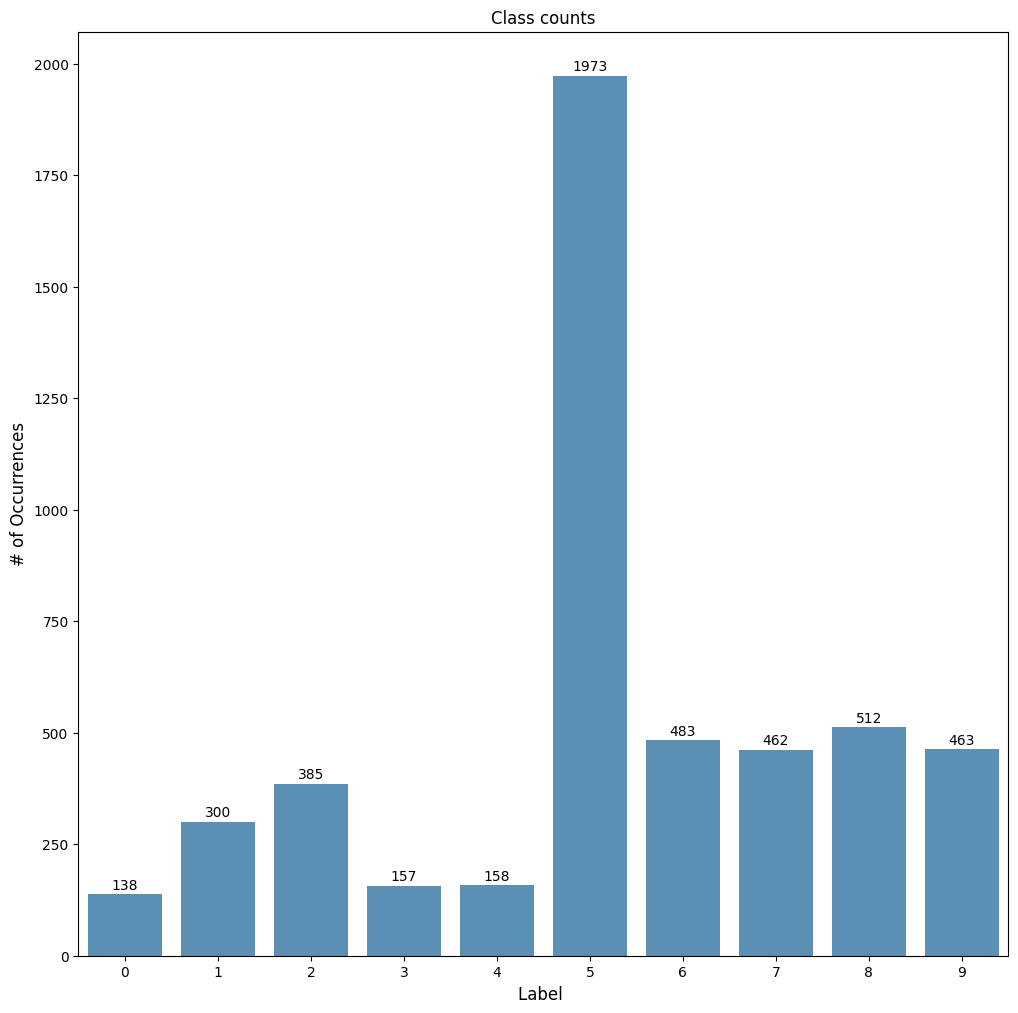

In [ ]:
x=train_data.iloc[:,2:].sum()
plt.figure(figsize=(12,12))
ax = sns.barplot(x.values, alpha=0.8)
plt.title("Class counts")
plt.ylabel('# of Occurrences', fontsize=12)
plt.xlabel('Label ', fontsize=12)

rects = ax.patches
labels = x.values
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha='center', va='bottom')

plt.show()

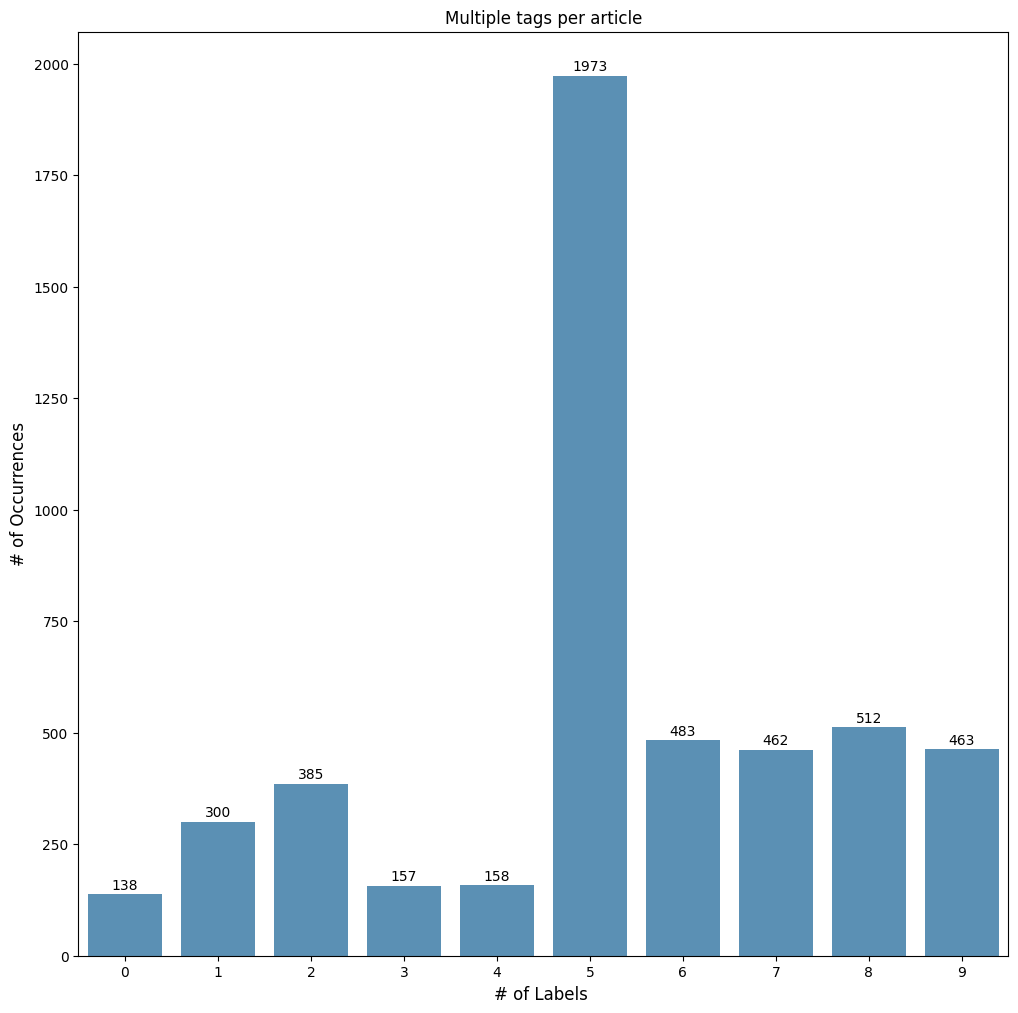

In [ ]:
plt.figure(figsize=(12,12))
ax = sns.barplot(x.values, alpha=0.8)
plt.title("Multiple tags per article")
plt.ylabel('# of Occurrences', fontsize=12)
plt.xlabel('# of Labels ', fontsize=12)

#adding the text labels
rects = ax.patches
labels = x.values
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha='center', va='bottom')

plt.show()

In [ ]:
#Remove Stopwords
# stop_words = set(stopwords.words('english'))

# # function to remove stopwords
# def remove_stopwords(text):
#     no_stopword_text = [w for w in text.split() if not w in stop_words]
#     return ' '.join(no_stopword_text)

#Clean Text
def clean_text(text):
    text = text.lower()
    text = re.sub("[^а-яА-Я]"," ",text)
    text = ' '.join(text.split())
    return text

#stemming
stemmer = SnowballStemmer("russian")
def stemming(sentence):
    stemSentence = ""
    for word in sentence.split():
        stem = stemmer.stem(word)
        stemSentence += stem
        stemSentence += " "
    stemSentence = stemSentence.strip()
    return stemSentence

# train_data['content'] = train_data['content'].apply(lambda x: remove_stopwords(x))
train_data['content'] = train_data['content'].apply(lambda x:clean_text(x))
train_data['content'] = train_data['content'].apply(stemming)

In [ ]:
train_data.head()

,id,content,straw_man,appeal_to_fear,fud,bandwagon,whataboutism,loaded_language,glittering_generalities,euphoria,cherry_picking,cliche
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,нов огляд мап в д рос йськ в йськов експерт ку...,0,0,0,0,0,1,0,1,0,0
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,недавн кварта ж стко поглум над русск баран ко...,0,0,0,0,0,1,0,0,1,0
2,e6a427f1-211f-405f-bd8b-70798458d656,тим час йд евакуац я б лгородськ автовокзал в ...,0,0,0,0,0,1,0,1,0,0
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,в укр н найближч час мают нам р посилит в дпов...,0,0,0,0,0,0,0,0,0,0
4,9c01de00-841f-4b50-9407-104e9ffb03bf,расч ты мм са с гвоздик й бригад го ак й арм ю...,0,0,0,0,0,1,0,0,0,0


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_data['content'], train_data.iloc[:, 2:], test_size=0.15, random_state=42
)

In [ ]:
# pipeline = Pipeline([
#                 ('tfidf', TfidfVectorizer()),
#                 ('clf', BinaryRelevance(LogisticRegression(solver='sag'))),
#             ])
# pipeline.fit(X_train, y_train)
# predictions = pipeline.predict(X_val)


# print('Accuracy = ', accuracy_score(y_val,predictions))
# print('F1 score is ',f1_score(y_val, predictions, average="micro"))
# print('Hamming Loss is ', hamming_loss(y_val, predictions))


pipeline = Pipeline([
                ('tfidf', TfidfVectorizer()),
                ('clf', ClassifierChain(LogisticRegression(solver='sag'))),
            ])
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_val)


print('Accuracy = ', accuracy_score(y_val,predictions))
print('F1 score is ',f1_score(y_val, predictions, average="micro"))
print('Hamming Loss is ', hamming_loss(y_val, predictions))


Accuracy =  0.4059233449477352
F1 score is  0.4238143289606458
Hamming Loss is  0.0994773519163763


In [ ]:
mlb = MultiLabelBinarizer()
mlb.fit_transform(df['techniques'])

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 1, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 1]])

In [ ]:
print(classification_report(y_val, predictions, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00        15
              bandwagon       0.00      0.00      0.00        42
         cherry_picking       1.00      0.02      0.03        59
                 cliche       0.00      0.00      0.00        28
               euphoria       0.00      0.00      0.00        21
                    fud       0.75      0.66      0.70       288
glittering_generalities       0.89      0.25      0.39        65
        loaded_language       1.00      0.05      0.09        61
              straw_man       0.00      0.00      0.00        68
           whataboutism       0.00      0.00      0.00        66

              micro avg       0.76      0.29      0.42       713
              macro avg       0.36      0.10      0.12       713
           weighted avg       0.55      0.29      0.33       713
            samples avg       0.35      0.22      0.25       713



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
# Load files
df_test = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/test.csv")
df_solution = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/solution.csv")

# Merge test and labels by 'id'
test_data = df_test.merge(df_solution, on='id')

# Drop non-label columns
technique_columns = [
    'straw_man', 'appeal_to_fear', 'fud', 'bandwagon', 'whataboutism',
    'loaded_language', 'glittering_generalities', 'euphoria',
    'cherry_picking', 'cliche'
]
X_test = df['content'].tolist()
y_test = df[technique_columns].values

In [ ]:
test_data['appeal_to_fear'].sum()

np.int64(449)

In [ ]:
predictions = pipeline.predict(X_test)


print('Accuracy = ', accuracy_score(y_test,predictions))
print('F1 score is ',f1_score(y_test, predictions, average="micro"))
print('Hamming Loss is ', hamming_loss(y_test, predictions))

Accuracy =  0.3448456305599163
F1 score is  0.42745367192862044
Hamming Loss is  0.10913134484563056


In [ ]:
predictions

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 2254 stored elements and shape (3822, 10)>

In [ ]:
predicted_labels = [technique_columns[i] for i in predictions]
true_labels = mlb.inverse_transform(y_test)

# Print example
for i in range(5):
    print(f"\nText: {X_test[i][:80]}...")
    print("True:", true_labels[i])
    print("Pred:", predicted_labels[i])


Text: Новий огляд мапи DeepState від російського військового експерта, кухара путіна 2...
True: ('fud', 'loaded_language')
Pred: ('fud',)

Text: Недавно 95 квартал жёстко поглумился над русскими баранами, которые притворяются...
True: ('fud', 'straw_man')
Pred: ('fud',)

Text: 🤩
Тим часом йде евакуація Бєлгородського автовокзалу - він оточений з невідомих ...
True: ('fud', 'loaded_language')
Pred: ('fud',)

Text: В Україні найближчим часом мають намір посилити відповідальність за ухилення від...
True: ()
Pred: ()

Text: Расчёты 122-мм САУ 2С1 "Гвоздика" 132-й бригады 1-го АК 8-й армии ЮВО ВС России ...
True: ('fud',)
Pred: ()


In [ ]:
print(classification_report(y_test, predictions, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00       138
              bandwagon       0.00      0.00      0.00       300
         cherry_picking       0.64      0.04      0.08       385
                 cliche       0.00      0.00      0.00       157
               euphoria       0.00      0.00      0.00       158
                    fud       0.69      0.77      0.73      1973
glittering_generalities       0.81      0.04      0.07       483
        loaded_language       0.50      0.00      0.00       462
              straw_man       0.53      0.02      0.03       512
           whataboutism       0.00      0.00      0.00       463

              micro avg       0.69      0.31      0.43      5031
              macro avg       0.32      0.09      0.09      5031
           weighted avg       0.50      0.31      0.30      5031
            samples avg       0.40      0.24      0.28      5031



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
# technique_labels[0]

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [ ]:
# # Binarize labels
# mlb = MultiLabelBinarizer()
# y = mlb.fit_transform(df['techniques'])

# # Train/test split
# X_train, X_val, y_train, y_val = train_test_split(
#     df['content'], y, test_size=0.15, random_state=42
# )

In [ ]:
# vectorizer = TfidfVectorizer(
#     max_features=5000,
#     ngram_range=(1, 2),
#     stop_words=None
# )

# X_train_tfidf = vectorizer.fit_transform(X_train)
# X_val_tfidf = vectorizer.transform(X_val)

In [ ]:
# model = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0))
# model.fit(X_train_tfidf, y_train)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [ ]:
# y_pred = model.predict(X_val_tfidf)

# print(classification_report(y_val, y_pred, target_names=mlb.classes_))

                         precision    recall  f1-score   support

         appeal_to_fear       0.00      0.00      0.00        42
              bandwagon       0.00      0.00      0.00        28
         cherry_picking       0.67      0.06      0.11        68
                 cliche       0.00      0.00      0.00        66
               euphoria       1.00      0.03      0.06        61
                    fud       0.67      0.07      0.12        59
glittering_generalities       0.90      0.14      0.24        65
        loaded_language       0.71      0.76      0.74       288
              straw_man       0.00      0.00      0.00        15
           whataboutism       0.00      0.00      0.00        21

              micro avg       0.72      0.34      0.46       713
              macro avg       0.39      0.11      0.13       713
           weighted avg       0.57      0.34      0.35       713
            samples avg       0.39      0.25      0.29       713



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
# predicted_labels = mlb.inverse_transform(y_pred)
# true_labels = mlb.inverse_transform(y_val)

# # Print example
# for i in range(5):
#     print(f"\nText: {X_val.iloc[i][:80]}...")
#     print("True:", true_labels[i])
#     print("Pred:", predicted_labels[i])


Text: ⚡️
У Черкасах на деяких вулицях немає електропостачання 
Відключення триватиме д...
True: ()
Pred: ()

Text: 💥
 
Броневики и танки разнесло на куски:
 кадры уничтожения российской артиллери...
True: ('euphoria', 'loaded_language')
Pred: ()

Text: Гвардійці з Бахмута передають, що все стабільно і у ворогів не виходять штурмові...
True: ('cliche',)
Pred: ('loaded_language',)

Text: ❗️
Молдавские парламентарии поднимут на заседании Парламентской ассамблеи (ПА) О...
True: ('cherry_picking',)
Pred: ()

Text: ПЗДЦ: напоили 7-летнего ребенка алкашкой
 в Кривом Роге
. 
На остановке заметили...
True: ('loaded_language',)
Pred: ()


Roberta chat based

In [ ]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['techniques'])

# Save classes for later use
technique_labels = mlb.classes_
print("Techniques:", technique_labels)


Techniques: ['appeal_to_fear' 'bandwagon' 'cherry_picking' 'cliche' 'euphoria' 'fud'
 'glittering_generalities' 'loaded_language' 'straw_man' 'whataboutism']


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df['content'], y, test_size=0.15, random_state=42
)

In [ ]:
print(max([len(i) for i in X_train]))

4124


In [ ]:
from transformers import AutoTokenizer

model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
tokenizer.model_max_length

512

In [ ]:
# Tokenize text
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=512)

In [ ]:
import torch
from torch.utils.data import Dataset

class TechniqueDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'labels': self.labels[idx]
        }

    def __len__(self):
        return len(self.labels)

train_dataset = TechniqueDataset(train_encodings, y_train)
val_dataset = TechniqueDataset(val_encodings, y_val)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(technique_labels),
    problem_type="multi_label_classification"
)
model.to('cuda')

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [ ]:
# del model # or any large variable
# gc.collect()
# torch.cuda.empty_cache()

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_several_epoch",
    eval_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_strategy = 'epoch',
    report_to="none"
)

# training_args = TrainingArguments(
#     output_dir="./results",
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     evaluation_strategy="epoch",
#     logging_dir="./logs",
#     report_to="none",  # ⬅️ This disables wandb
# )
# Custom metrics
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

def compute_metrics(pred):
    logits, labels = pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs > 0.5).astype(int)
    return {
        'f1': f1_score(labels, preds, average='micro'),
        'precision': precision_score(labels, preds, average='micro'),
        'recall': recall_score(labels, preds, average='micro')
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.300334,0.256169,0.789855,0.152875
2,0.337900,0.261116,0.469328,0.767516,0.338008
3,0.270600,0.255173,0.521101,0.753316,0.398317
4,0.248700,0.253154,0.542525,0.750000,0.424965
5,0.220200,0.267162,0.501398,0.747222,0.377279
6,0.220200,0.278191,0.507326,0.730871,0.388499
7,0.197400,0.276129,0.508385,0.685714,0.403927
8,0.178600,0.279906,0.532878,0.681223,0.437588
9,0.168400,0.287930,0.513465,0.713217,0.401122
10,0.155900,0.287174,0.516814,0.700240,0.409537


TrainOutput(global_step=4060, training_loss=0.22138802429725385, metrics={'train_runtime': 3964.9992, 'train_samples_per_second': 8.192, 'train_steps_per_second': 1.024, 'total_flos': 8546460915793920.0, 'train_loss': 0.22138802429725385, 'epoch': 10.0})

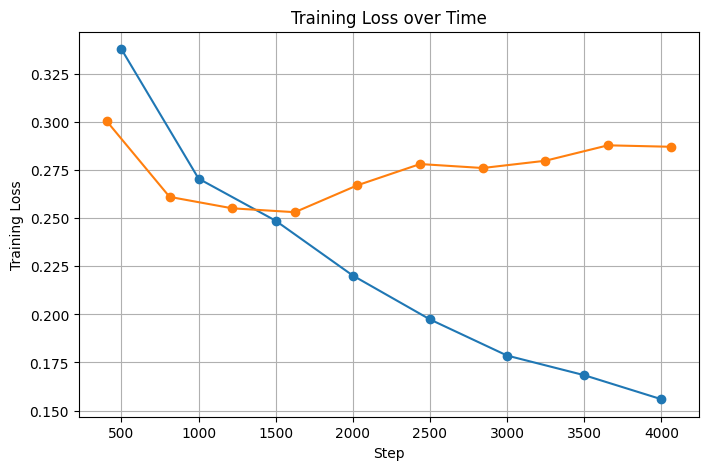

In [ ]:
import matplotlib.pyplot as plt

# Extract log history from trainer
logs = trainer.state.log_history

# Get loss and step values
loss_vals = [log["loss"] for log in logs if "loss" in log]
loss_validation = [log["eval_loss"] for log in logs if "eval_loss" in log]
steps = [log["step"] for log in logs if "loss" in log]
steps_val = [log["step"] for log in logs if "eval_loss" in log]

# Plot loss over steps
plt.figure(figsize=(8, 5))
plt.plot(steps, loss_vals, marker='o')
plt.plot(steps_val, loss_validation, marker='o')
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss over Time")
plt.grid(True)
plt.show()

In [ ]:
# # Predict on validation set
# preds_raw = trainer.predict(val_dataset)
# probs = torch.sigmoid(torch.tensor(preds_raw.predictions)).numpy()
# preds_binary = (probs > 0.5).astype(int)

# # Decode techniques
# decoded_preds = mlb.inverse_transform(preds_binary)
# decoded_true = mlb.inverse_transform(y_val)

# # Example
# for i in range(5):
#     print(f"\nText: {X_val.iloc[i][:80]}...")
#     print("True:", decoded_true[i])
#     print("Pred:", decoded_preds[i])

In [ ]:
!zip -r result_epoch.zip /content/results_several_epoch

  adding: content/results_several_epoch/ (stored 0%)
  adding: content/results_several_epoch/checkpoint-1624/ (stored 0%)
  adding: content/results_several_epoch/checkpoint-1624/scheduler.pt (deflated 56%)
  adding: content/results_several_epoch/checkpoint-1624/config.json (deflated 57%)
  adding: content/results_several_epoch/checkpoint-1624/optimizer.pt (deflated 66%)
  adding: content/results_several_epoch/checkpoint-1624/trainer_state.json (deflated 67%)
  adding: content/results_several_epoch/checkpoint-1624/training_args.bin (deflated 52%)
  adding: content/results_several_epoch/checkpoint-1624/model.safetensors (deflated 27%)
  adding: content/results_several_epoch/checkpoint-1624/rng_state.pth (deflated 25%)


In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, Dataset

# Load files
df_test = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/test.csv")
df_solution = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/solution.csv")

# Merge test and labels by 'id'
df = df_test.merge(df_solution, on='id')

# Drop non-label columns
label_columns = [
    'straw_man', 'appeal_to_fear', 'fud', 'bandwagon', 'whataboutism',
    'loaded_language', 'glittering_generalities', 'euphoria',
    'cherry_picking', 'cliche'
]
X_texts = df['content'].tolist()
y_true = df[label_columns].values

# Load tokenizer (same as used during training)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Custom dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# Create dataset and dataloader
batch_size = 8  # reduce if you still get OOM
dataset = TextDataset(X_texts, y_true, tokenizer)
loader = DataLoader(dataset, batch_size=batch_size)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# model.eval()




In [ ]:
test_encodings = tokenizer(list(X_texts), truncation=True, padding=True, max_length=512)

In [ ]:
test_dataset = TechniqueDataset(test_encodings, y_true)

In [ ]:
# from transformers import Trainer
# from sklearn.metrics import classification_report
# import numpy as np

# # Prepare the test dataset in Dataset format
# from datasets import Dataset
# test_dataset = Dataset.from_dict(encodings)
# test_dataset = test_dataset.add_column("labels", y_true.tolist())

# Run prediction
predictions = trainer.predict(test_dataset)

# `predictions.predictions` contains raw logits
probs = torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
y_pred_binary = (probs >= 0.5).astype(int)

# Evaluate
print("Classification Report:\n")
print(classification_report(y_true, y_pred_binary, target_names=label_columns))


Classification Report:

                         precision    recall  f1-score   support

              straw_man       0.00      0.00      0.00       207
         appeal_to_fear       0.00      0.00      0.00       449
                    fud       0.50      0.20      0.29       576
              bandwagon       0.29      0.05      0.08       236
           whataboutism       0.00      0.00      0.00       235
        loaded_language       0.85      0.04      0.07      2959
glittering_generalities       0.68      0.62      0.65       723
               euphoria       0.15      0.68      0.25       695
         cherry_picking       0.00      0.00      0.00       768
                 cliche       0.00      0.00      0.00       695

              micro avg       0.28      0.15      0.20      7543
              macro avg       0.25      0.16      0.13      7543
           weighted avg       0.46      0.15      0.14      7543
            samples avg       0.15      0.10      0.11      7543

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
# Predict in batches
all_preds = []

with torch.no_grad():
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = trainer.predict(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        all_preds.append(probs)

# Combine predictions
import numpy as np
y_pred = np.vstack(all_preds)
y_pred_binary = (y_pred >= 0.5).astype(int)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_true, y_pred_binary, target_names=label_columns))

TypeError: Trainer.predict() got an unexpected keyword argument 'input_ids'

In [ ]:
from transformers import Trainer
from sklearn.metrics import classification_report
import numpy as np

# Prepare the test dataset in Dataset format
from datasets import Dataset
test_dataset = Dataset.from_dict(encodings)
test_dataset = test_dataset.add_column("labels", y_true.tolist())

# Run prediction
predictions = trainer.predict(test_dataset)

# `predictions.predictions` contains raw logits
probs = torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
y_pred_binary = (probs >= 0.5).astype(int)

# Evaluate
print("Classification Report:\n")
print(classification_report(y_true, y_pred_binary, target_names=label_columns))

In [ ]:
# final_test = pd.read_csv('/content/test.csv')
# final_test

In [ ]:
# final_lab = pd.read_csv('/content/solution.csv')
# final_lab

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer
from sklearn.metrics import classification_report

# Load files
df_test = pd.read_csv("/content/test.csv")
df_solution = pd.read_csv("/content/solution.csv")

# Merge test and labels by 'id'
df = df_test.merge(df_solution, on='id')

# Drop non-label columns
label_columns = [
    'straw_man', 'appeal_to_fear', 'fud', 'bandwagon', 'whataboutism',
    'loaded_language', 'glittering_generalities', 'euphoria',
    'cherry_picking', 'cliche'
]
half_df = df[:]
X_texts = df['content'].tolist()
y_true = df[label_columns].values

# Load tokenizer (same as used during training)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize
encodings = tokenizer(
    X_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)



# Predict
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in encodings.items()}
    outputs = model(**inputs)
    probs = torch.sigmoid(outputs.logits).cpu().numpy()

# Thresholding
y_pred = (probs >= 0.5).astype(int)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_columns))


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.40 GiB. GPU 0 has a total capacity of 14.74 GiB of which 5.04 GiB is free. Process 4357 has 9.70 GiB memory in use. Of the allocated memory 9.52 GiB is allocated by PyTorch, and 63.13 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# Upload model(if exist)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/Roberta_for_unlp/results_several_epoch/checkpoint-406', num_labels=10, problem_type="multi_label_classification")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
# Device setup
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer
from sklearn.metrics import classification_report

# Load files
df_test = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/test.csv")
df_solution = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/solution.csv")

# Merge test and labels by 'id'
df = df_test.merge(df_solution, on='id')

# Drop non-label columns
label_columns = [
    'straw_man', 'appeal_to_fear', 'fud', 'bandwagon', 'whataboutism',
    'loaded_language', 'glittering_generalities', 'euphoria',
    'cherry_picking', 'cliche'
]
half_df = df.iloc[:2500]
X_texts = half_df['content'].tolist()
y_true = half_df[label_columns].values

# Load tokenizer (same as used during training)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize
encodings = tokenizer(
    X_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)



In [ ]:
half_df

,id,content,straw_man,appeal_to_fear,fud,bandwagon,whataboutism,loaded_language,glittering_generalities,euphoria,cherry_picking,cliche,Usage
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...",0,0,1,0,0,1,0,0,0,0,Public
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,0,0,0,0,0,1,0,0,0,0,Public
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,0,0,0,0,0,1,0,0,0,0,Public
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,0,0,0,0,0,0,0,0,0,0,Public
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,0,0,0,0,0,1,0,0,0,0,Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,7e414921-54be-45fe-9131-85d8b1ae6838,Схиляємо голови перед Захисниками України.\nШа...,0,0,0,0,0,0,1,0,0,0,Private
2496,0adfa579-f025-4c40-8181-6fb0fed91b01,"🇬🇧\n Ви, певне, вже бачили зворушливе відео, н...",0,0,0,0,0,0,1,0,0,0,Private
2497,a120ad9a-c580-477e-a110-aee9875c49fc,"#сплетни\n \nПошли сплетни, что у ТЦК и госуда...",1,1,0,0,0,1,0,0,1,0,Private
2498,0ee21de4-c1b3-4329-9640-1eb533e16558,"Друзі, я звертаюся до киян. Мені потрібна ваша...",0,0,0,0,0,1,0,0,0,0,Private


In [ ]:
# Predict
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in encodings.items()}
    outputs = model(**inputs)
    probs = torch.sigmoid(outputs.logits).cpu().numpy()

# Thresholding
y_pred = (probs >= 0.5).astype(int)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_columns))

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.66 GiB. GPU 0 has a total capacity of 14.74 GiB of which 2.51 GiB is free. Process 3866 has 12.23 GiB memory in use. Of the allocated memory 12.05 GiB is allocated by PyTorch, and 65.48 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, Dataset

# Load files
df_test = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/test.csv")
df_solution = pd.read_csv("/content/drive/MyDrive/Roberta_for_unlp/solution.csv")

# Merge test and labels by 'id'
df = df_test.merge(df_solution, on='id')

# Drop non-label columns
label_columns = [
    'straw_man', 'appeal_to_fear', 'fud', 'bandwagon', 'whataboutism',
    'loaded_language', 'glittering_generalities', 'euphoria',
    'cherry_picking', 'cliche'
]
X_texts = df['content'].tolist()
y_true = df[label_columns].values

# Load tokenizer (same as used during training)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Custom dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# Create dataset and dataloader
batch_size = 8  # reduce if you still get OOM
dataset = TextDataset(X_texts, y_true, tokenizer)
loader = DataLoader(dataset, batch_size=batch_size)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()




XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [ ]:
# Predict in batches
all_preds = []

with torch.no_grad():
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        all_preds.append(probs)

# Combine predictions
import numpy as np
y_pred = np.vstack(all_preds)
y_pred_binary = (y_pred >= 0.5).astype(int)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_true, y_pred_binary, target_names=label_columns))

Classification Report:

                         precision    recall  f1-score   support

              straw_man       0.00      0.00      0.00       207
         appeal_to_fear       0.00      0.00      0.00       449
                    fud       0.00      0.00      0.00       576
              bandwagon       0.00      0.00      0.00       236
           whataboutism       0.00      0.00      0.00       235
        loaded_language       0.00      0.00      0.00      2959
glittering_generalities       0.00      0.00      0.00       723
               euphoria       0.10      0.25      0.15       695
         cherry_picking       0.00      0.00      0.00       768
                 cliche       0.00      0.00      0.00       695

              micro avg       0.10      0.02      0.04      7543
              macro avg       0.01      0.03      0.01      7543
           weighted avg       0.01      0.02      0.01      7543
            samples avg       0.03      0.01      0.02      7543

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

# My own architecture